# AR Catalog Tutorial

Jimmy Butler, September 2024

In [14]:
import pandas as pd
import xarray as xr
import numpy as np
import os
from pathlib import Path
import seaborn as sns
import xarray as xr

repo_dir = str(Path(os.getcwd()).parents[0])

Dataframes are divided into years (hence just loading up the 2020 data). However, cluster labelling is consistent with previous years (so, first storm in the 2020 data will be the $n$th storm since 1980, and $n$ will be the label assigned to that storm)

In [15]:
path = repo_dir + '/data/ar_database/dataframes/2022_storm_df.h5'
storms = pd.read_hdf(path)

Each row is a storm that was identified for that particular year.

In [16]:
storms.index

Index([8099.0, 8100.0, 8101.0, 8102.0, 8103.0, 8104.0, 8105.0, 8106.0, 8107.0,
       8108.0,
       ...
       8314.0, 8315.0, 8316.0, 8317.0, 8318.0, 8319.0, 8320.0, 8321.0, 8322.0,
       8323.0],
      dtype='float64', name='cluster', length=221)

In [17]:
storms.columns

Index(['data_array', 'is_landfalling'], dtype='object')

'data_array' column consists of xarray DataArray binary masks for each storm, with time, lat, lon dimensions properly subsetted to contain the full storm.

Let's look at our good ol' friend: the AR responsible for the 2022 Antarctic Heat Wave!

In [26]:
storms.data_array.iloc[37]

<xarray.DataArray 'clust' (time: 38, lat: 93, lon: 253)> Size: 894kB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=int8)
Coordinates:
  * time     (time) datetime64[ns] 304B 2022-03-13T15:00:00 ... 2022-03-18T06...
  * lat      (lat) float64 744B -85.0 -84.5 -84.0 -83.5 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 2kB -3.125 -2.5 -1.875 -1.25 ... 153.1 153.8 154.4

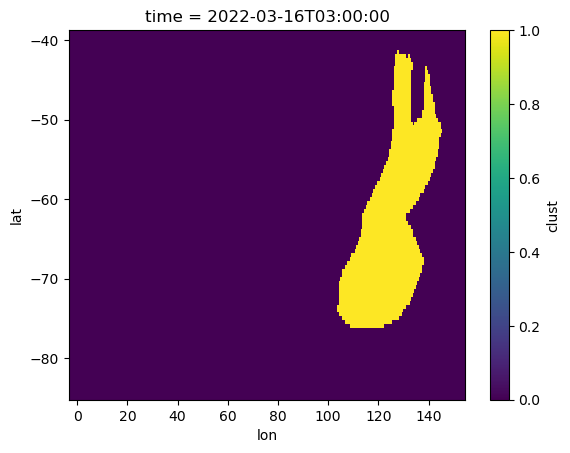

In [35]:
storms.data_array.iloc[37].isel(time=20).plot.imshow()

'is_landfalling' just indicates whether that storm makes landfall over the AIS at any point in its lifetime.

**Warning:** try to avoid printing out the dataframe or displaying it in a notebook when the 'data_array' column is included. pandas doesn't know how to display a Series whose objects are xarray DataArrays, and so it just displays a string serialization that takes FOREVER to execute. Save yourself time and exclude that column if yo